In [48]:
train_sets = ['../data/processed/smooth_2023.csv', '../data/processed/smooth_ewm_2023.csv', '../data/raw/sample_23.csv']
test_set = '../data/raw/sample_24.csv'

SAMPLE_SIZE = 3000
CLUSTERS_COUNT = 7
RANDOM_STATE = 42

In [47]:
#%pip install tslearn
#%pip install matplotlib

import numpy as np
from tslearn.clustering import KShape
from tslearn.utils import to_time_series_dataset
import matplotlib.pyplot as plt

In [49]:
import csv

def extract_values(filepath):
    """Helper function to read a CSV and return a list of numerical rows."""
    data = []
    with open(filepath, mode='r') as file:
        csv_reader = csv.reader(file)
        headers = next(csv_reader)[1:]
        
        for row in csv_reader:
            numeric_row = [float(val) for val in row[1:]]
            data.append(numeric_row)
            
    return headers, data

def calculate_copy_paste(train_data, test_data):
    headers_23, data_23 = extract_values(train_data)
    headers_24, data_24 = extract_values(test_data)

    total_absolute_error = 0.0
    total_percentage_error = 0.0
    total_data_points = 0
    valid_mape_points = 0

    for row_23, row_24 in zip(data_23, data_24):
        for val_23, val_24 in zip(row_23, row_24):
            
            total_absolute_error += abs(val_23 - val_24)
            total_data_points += 1
            
            # 2. Calculate percentage error for MAPE
            if val_24 != 0: 
                total_percentage_error += abs((val_24 - val_23) / val_24)
                valid_mape_points += 1

    mae = total_absolute_error / total_data_points

    if valid_mape_points > 0:
        mape = (total_percentage_error / valid_mape_points) * 100
    else:
        mape = 0.0

    print(f"Mean Absolute Error (MAE): {mae:.4f} units")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

for train_set in train_sets:
    print(f"Evaluating copy-paste strategy for: {train_set}")
    calculate_copy_paste(train_set, test_set)

Evaluating copy-paste strategy for: ../data/processed/smooth_2023.csv
Mean Absolute Error (MAE): 8.8987 units
Mean Absolute Percentage Error (MAPE): 1683.06%
Evaluating copy-paste strategy for: ../data/processed/smooth_ewm_2023.csv
Mean Absolute Error (MAE): 8.8922 units
Mean Absolute Percentage Error (MAPE): 1668.93%
Evaluating copy-paste strategy for: ../data/raw/sample_23.csv
Mean Absolute Error (MAE): 3.8561 units
Mean Absolute Percentage Error (MAPE): 323.64%


In [50]:
def generate_clustering(train_data):
    data_array = np.array(train_data[:SAMPLE_SIZE])
    data_transposed = data_array.T

    formatted_data = to_time_series_dataset(data_transposed)

    ks = KShape(n_clusters=CLUSTERS_COUNT, n_init=1, random_state=RANDOM_STATE)
    ks.fit(formatted_data)

    print(ks.cluster_centers_.shape)
    print(ks.inertia_)

    return ks, formatted_data

clusterings = []
for train_set in train_sets:
    print(f"Generating clustering for: {train_set}")
    _, train_data = extract_values(train_set)
    train_data = np.array(train_data)
    clustering, formatted_data = generate_clustering(train_data)
    clusterings.append((clustering, formatted_data))

Generating clustering for: ../data/processed/smooth_2023.csv
(7, 3000, 1)
0.08080999683041758
Generating clustering for: ../data/processed/smooth_ewm_2023.csv
(7, 3000, 1)
0.08086460869391238
Generating clustering for: ../data/raw/sample_23.csv
(7, 3000, 1)
0.09131858446158742


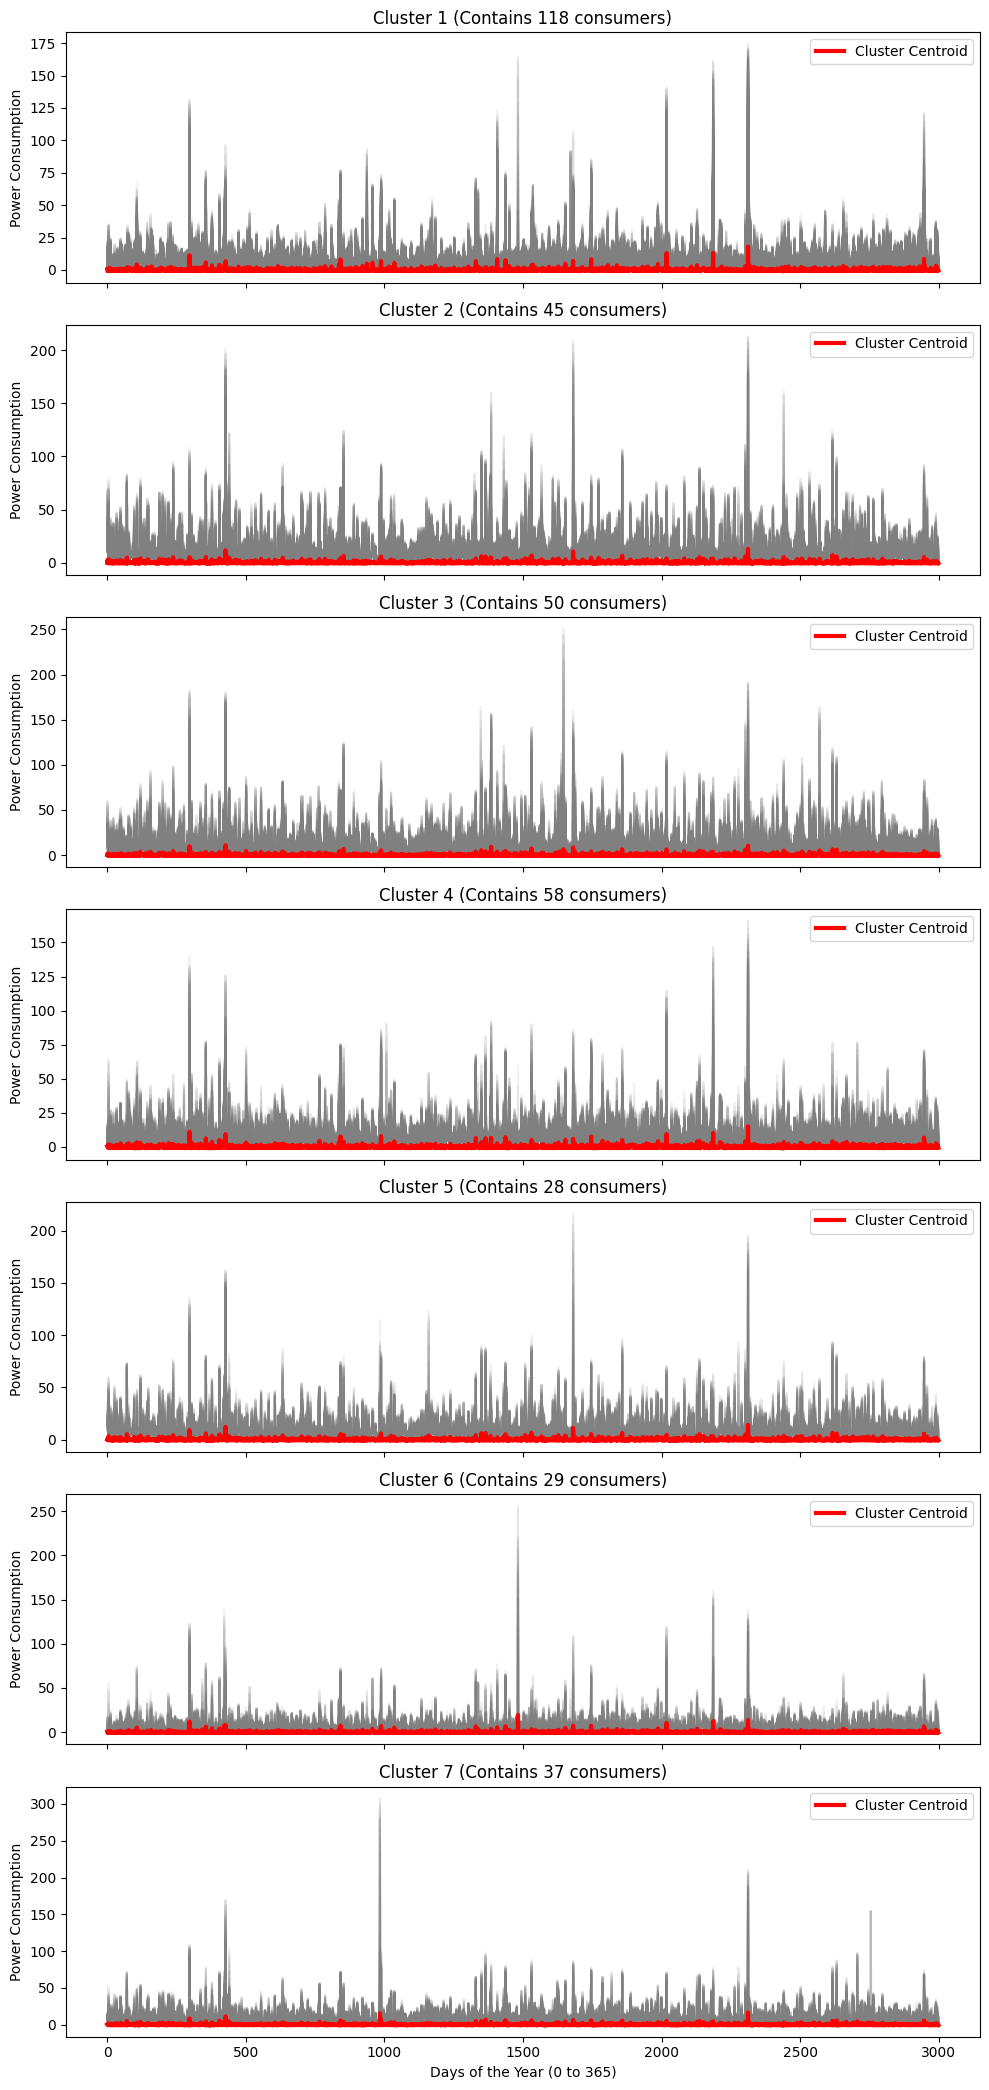

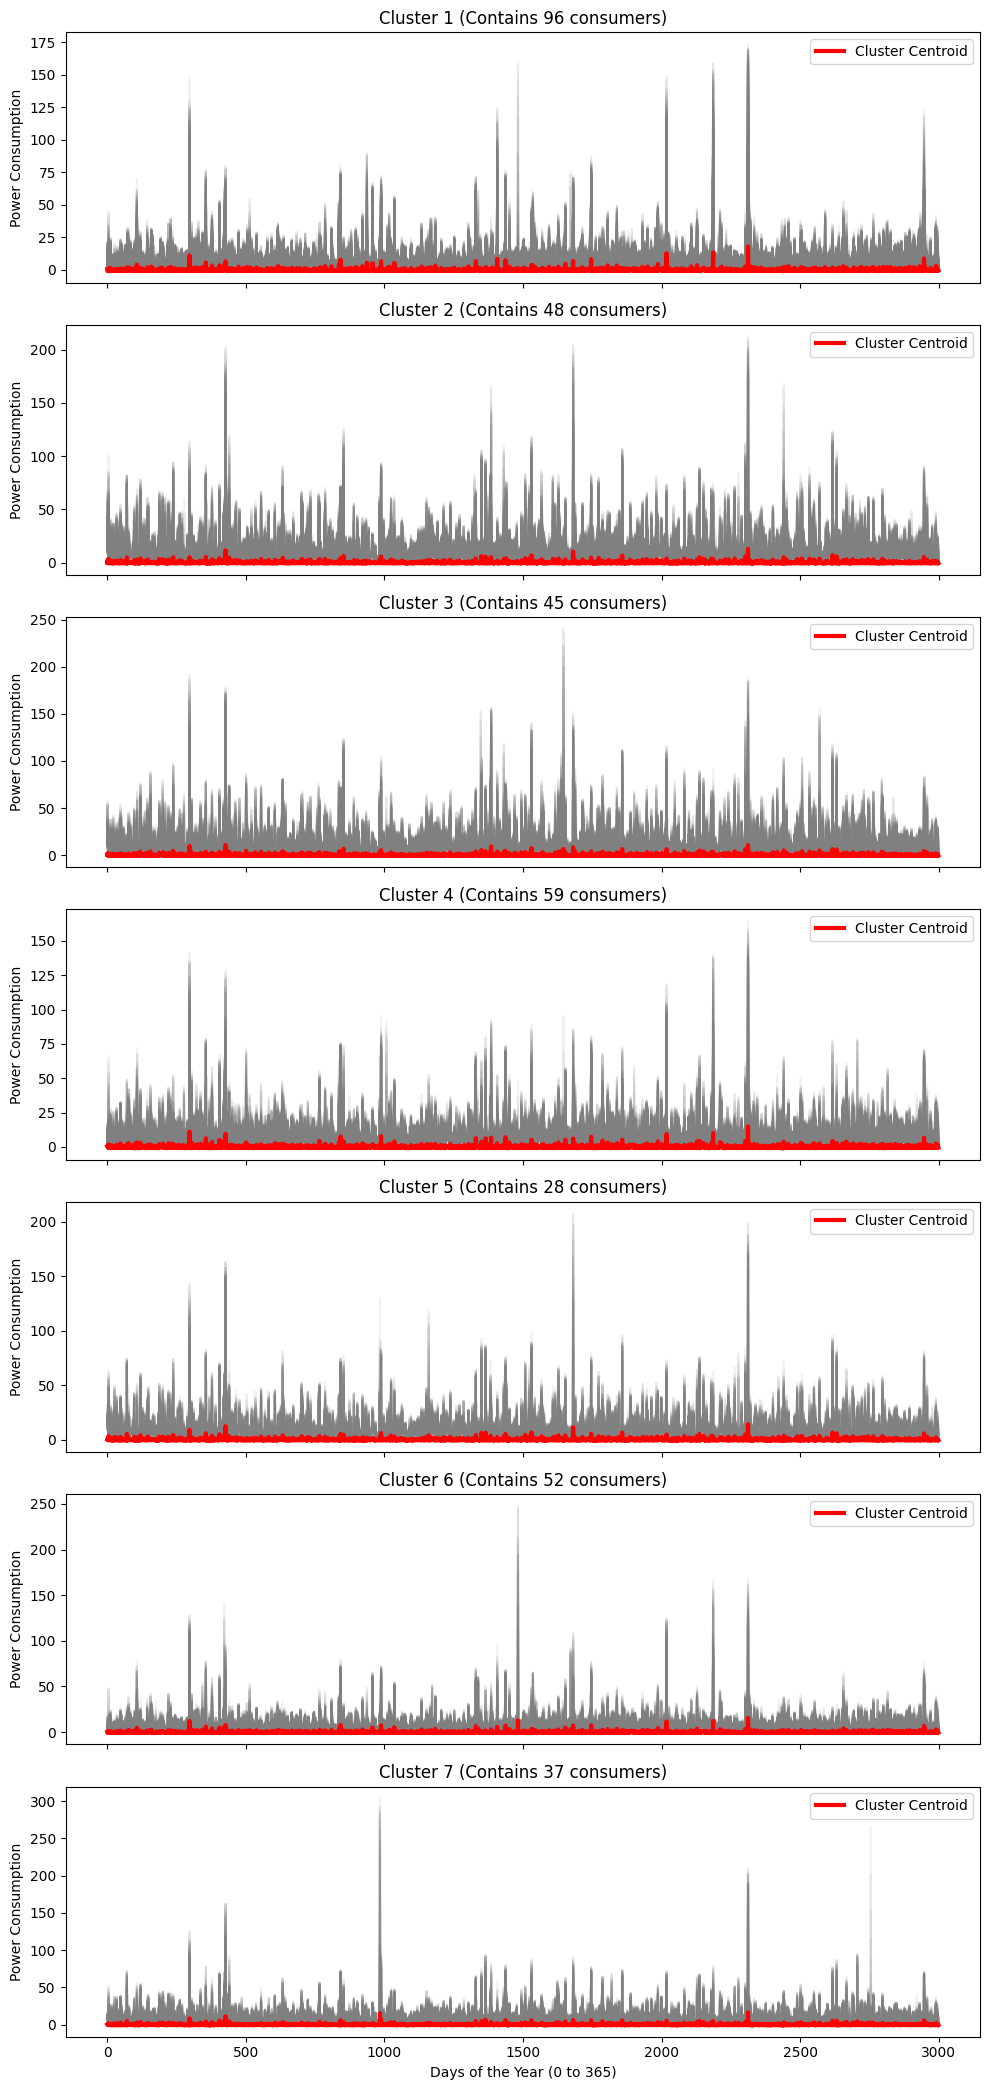

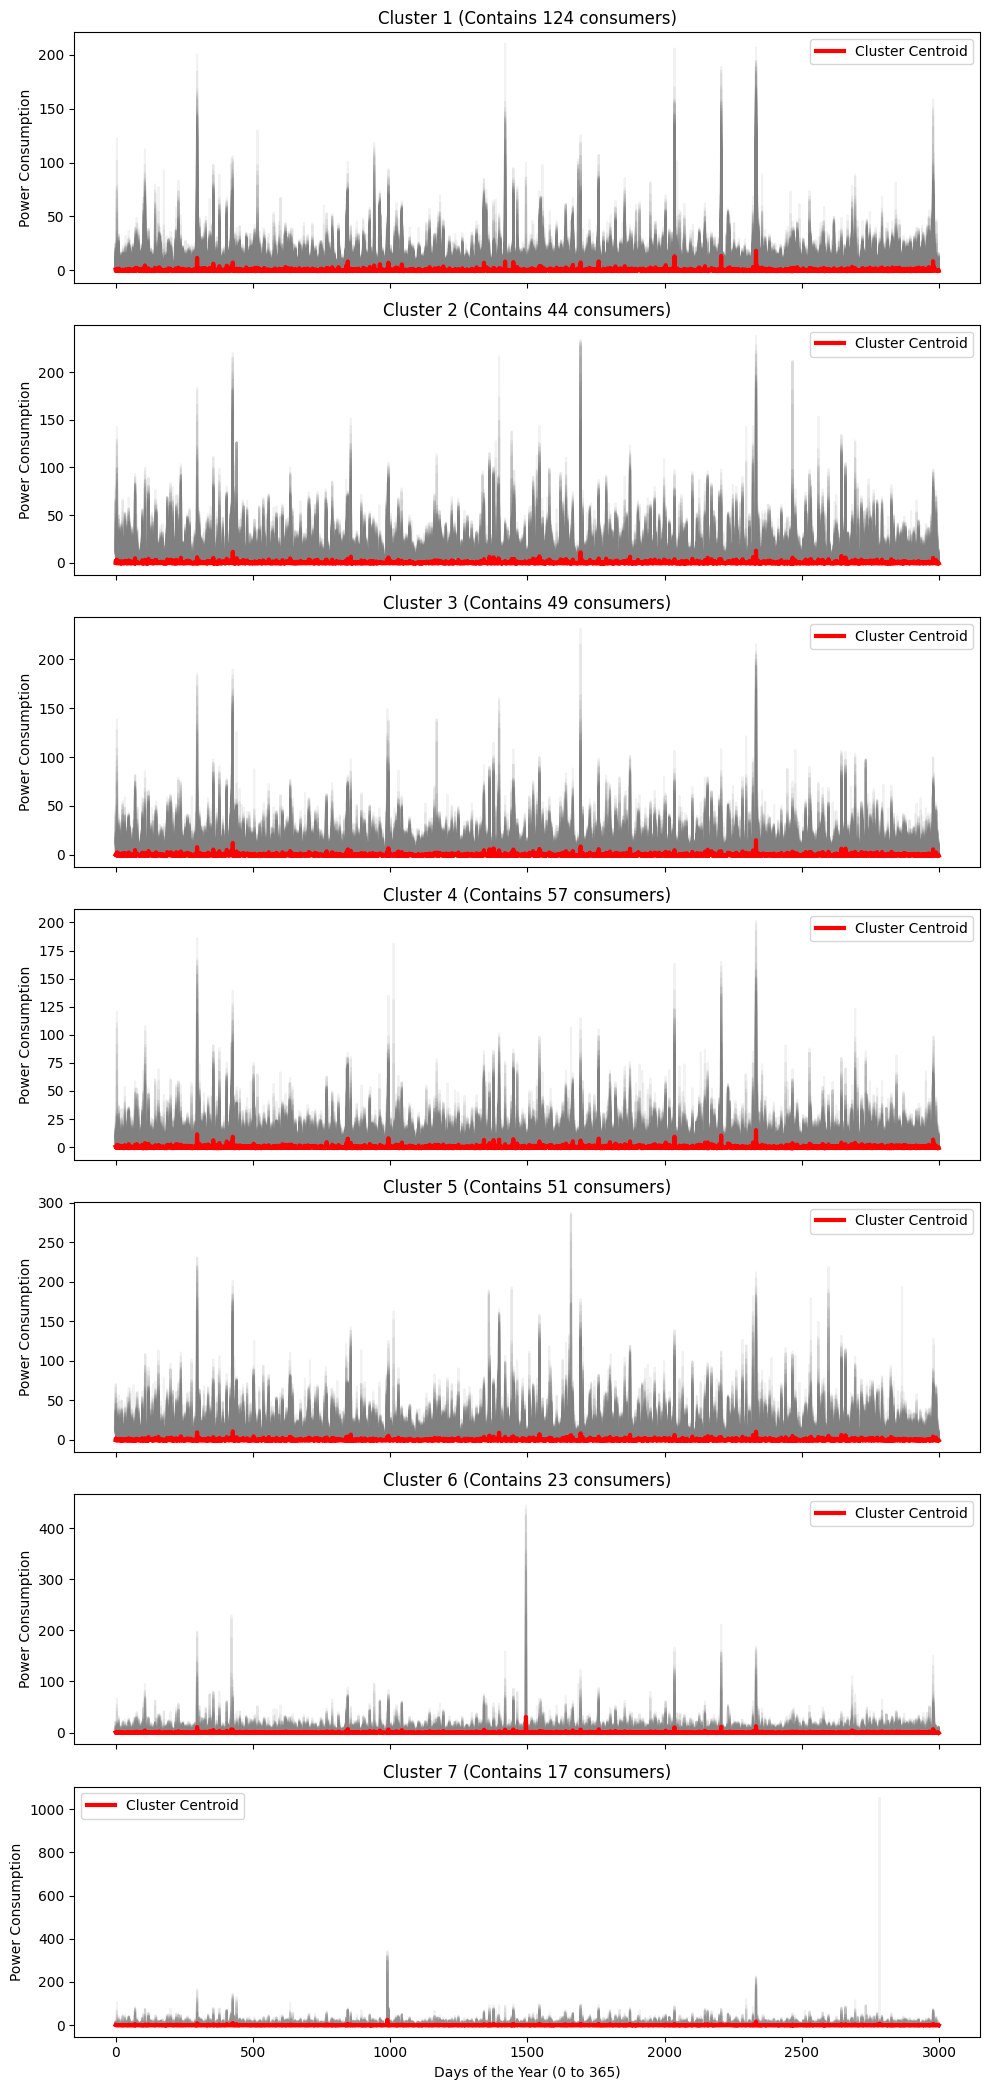

In [51]:
import matplotlib.pyplot as plt

def print_clusters(ks, formatted_data):
    labels = ks.labels_
    centers = ks.cluster_centers_
    optimal_k = len(centers)

    # Set up a grid of plots, one row for each cluster
    fig, axes = plt.subplots(optimal_k, 1, figsize=(10, 3 * optimal_k), sharex=True)

    # Ensure axes is a list just in case k=1
    if optimal_k == 1:
        axes = [axes]

    for i in range(optimal_k):
        # Find all consumer data assigned to cluster 'i'
        cluster_data = formatted_data[labels == i]
        
        # 1. Plot all the individual consumers in this cluster
        # We use a low alpha (transparency) so they don't turn into a solid block of color
        for series in cluster_data:
            axes[i].plot(series.ravel(), color='gray', alpha=0.1)
            
        # 2. Plot the final cluster center (the generalized "shape") on top in bold
        axes[i].plot(centers[i].ravel(), color='red', linewidth=3, label='Cluster Centroid')
        
        # Format the subplot
        axes[i].set_title(f"Cluster {i+1} (Contains {len(cluster_data)} consumers)")
        axes[i].set_ylabel("Power Consumption")
        axes[i].legend()

    # Format the overall figure
    plt.xlabel("Days of the Year (0 to 365)")
    plt.tight_layout() # Prevents labels from overlapping
    plt.show()

for clustering, formatted_data in clusterings:
    print_clusters(clustering, formatted_data)

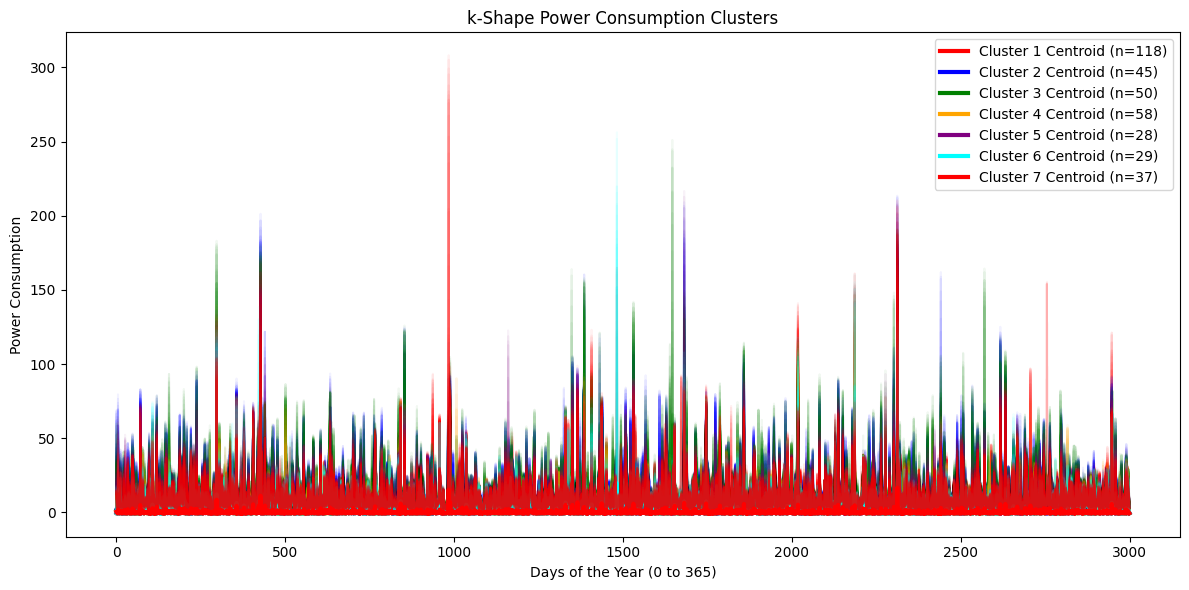

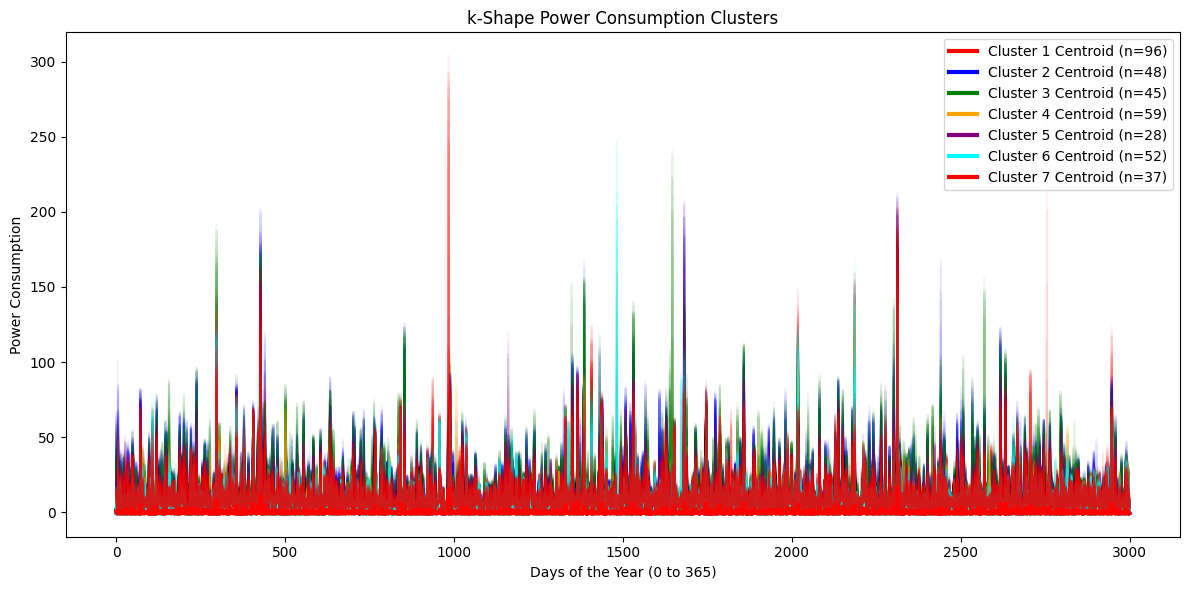

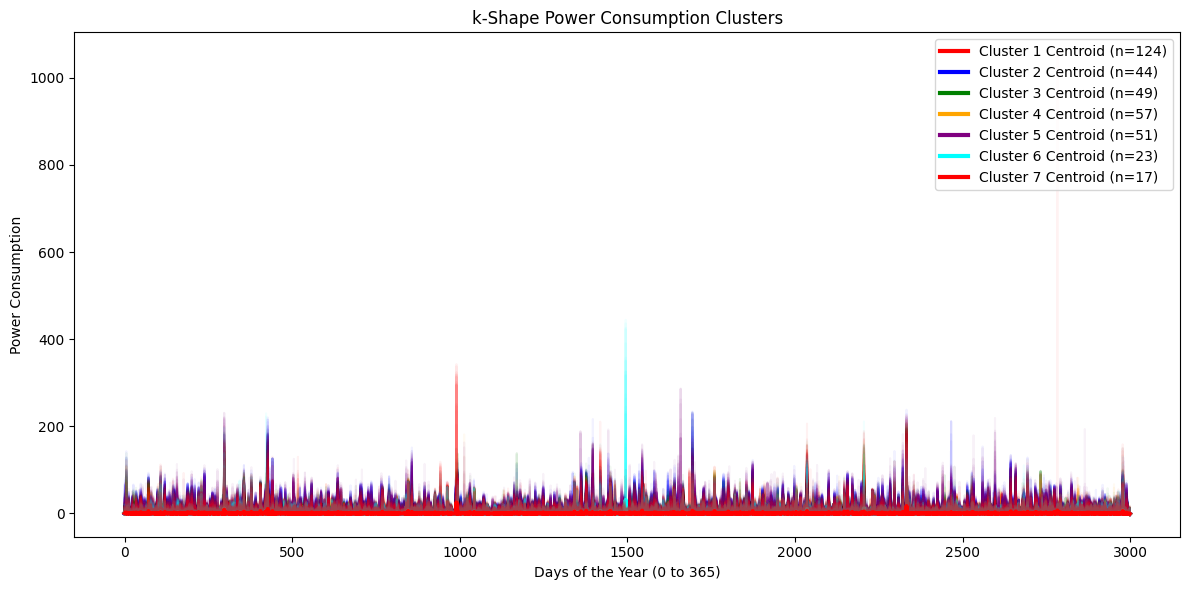

In [52]:
import matplotlib.pyplot as plt

def print_all_clusters(ks, formatted_data):
    labels = ks.labels_
    centers = ks.cluster_centers_
    optimal_k = len(centers)

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']

    # Set up a single, large plot
    plt.figure(figsize=(12, 6))

    for i in range(optimal_k):
        # Find all consumer data assigned to cluster 'i'
        cluster_data = formatted_data[labels == i]
        
        # Pick the color for this specific cluster
        cluster_color = colors[i % len(colors)]
        
        # 1. Plot all individual consumers in this cluster as a faint "cloud"
        # Alpha is very low (0.05) so the overlapping lines don't block everything out
        for series in cluster_data:
            plt.plot(series.ravel(), color=cluster_color, alpha=0.05)
            
        # 2. Plot the final cluster center (the generalized "shape") on top
        # We make it thick (linewidth=3) and fully opaque (alpha=1) so it stands out
        plt.plot(centers[i].ravel(), color=cluster_color, linewidth=3, 
                label=f'Cluster {i+1} Centroid (n={len(cluster_data)})')

    # Format the overall figure
    plt.title('k-Shape Power Consumption Clusters')
    plt.xlabel('Days of the Year (0 to 365)')
    plt.ylabel('Power Consumption')

    # Add the legend (it will only pick up the centroids because they have 'label=' assigned)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

for clustering, formatted_data in clusterings:
    print_all_clusters(clustering, formatted_data)